## High-resolution Land-Ocean Classification to demonstrate the impact of masked Slepians

## Code to Generate High-resolution Land-Ocean Dataset

Processing geometries...
Islands: 2800, Continents: 6

Generating training set...
  Uniform: 40000, Coastal: 30000, Island: 30000
  Sampling coastal points...
  Sampling island points...
  Classifying...
  Training set: 100000 points, 31853 land, 68147 ocean

Generating uniform test set...
  Uniform test: 100000 points

Generating coastline challenge test set...
  Coastline test: 100000 points

Generating island challenge test set...
  Island test: 100000 points

Saved:
  content/train100k.csv
  content/test_uniform100k.csv
  content/test_coastline100k.csv
  content/test_island100k.csv

DATASET SUMMARY
Train               : n=100000, land= 31.9%, island=  0.2%
Test (uniform)      : n=100000, land= 28.8%, island=  0.0%
Test (coastline)    : n=100000, land= 45.4%, island=  0.4%
Test (island)       : n=100000, land= 25.1%, island=  1.0%


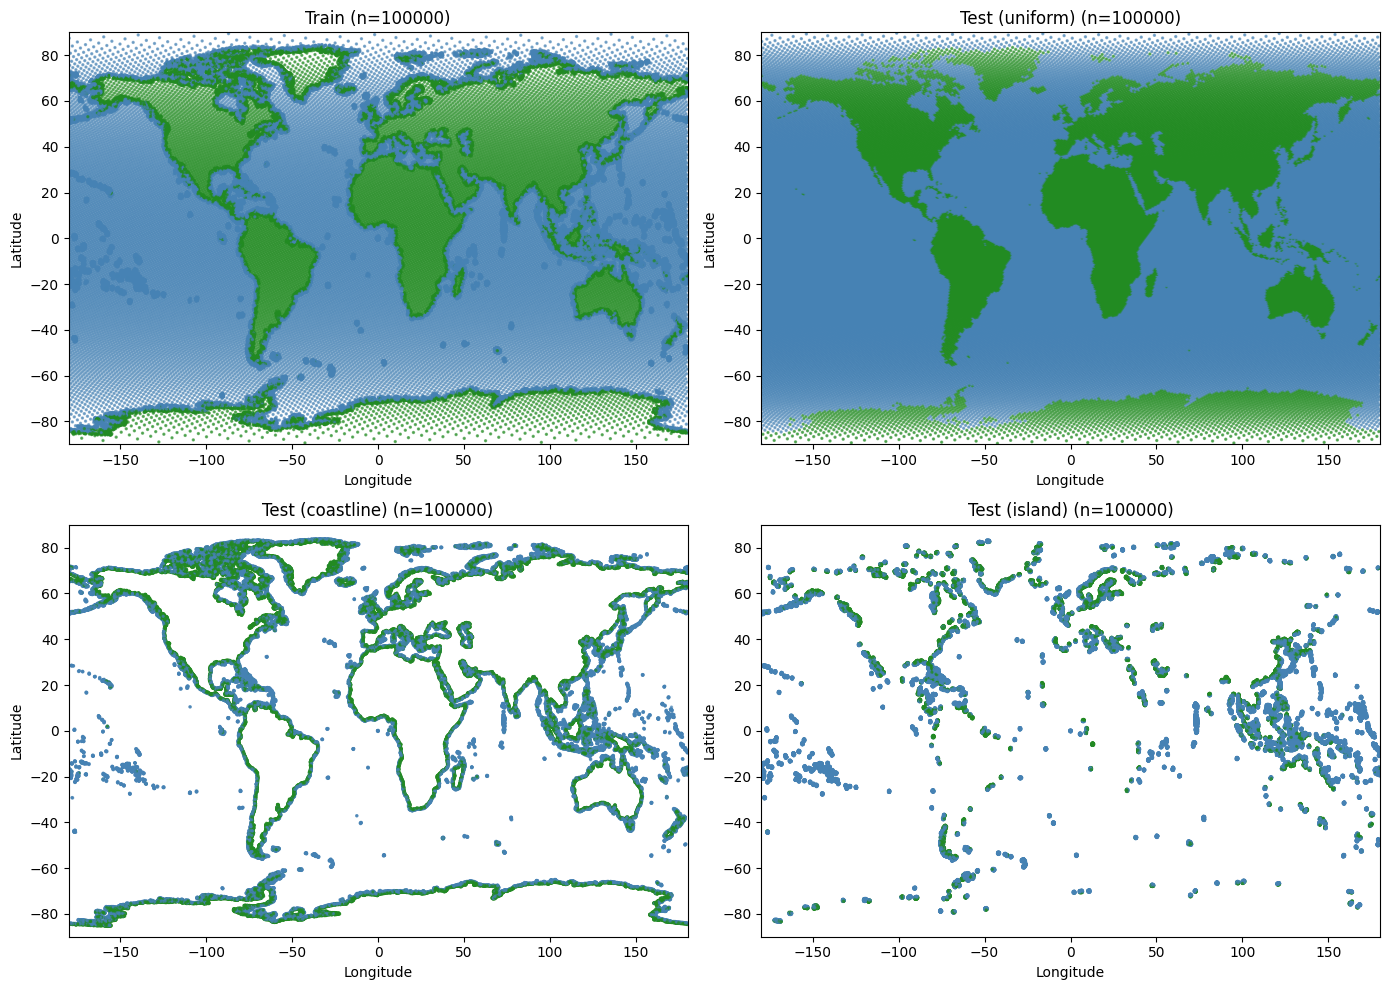

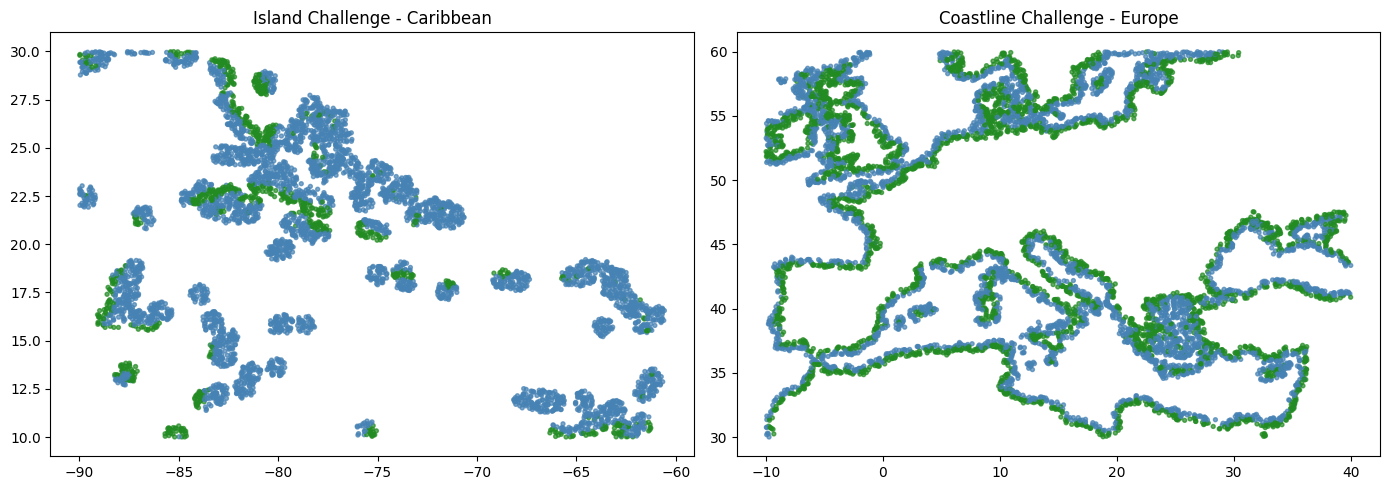

In [ ]:
# @title
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely import prepared
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import gc

# -----------------------------
# config
# -----------------------------
N_TRAIN = 100000
N_TEST_UNIFORM = 100000
N_TEST_COAST = 100000
N_TEST_ISLAND = 100000

SIMPLIFY_TOLERANCE = 0.005
SEED = 42

np.random.seed(SEED)

# -----------------------------
# download data
# -----------------------------
print("Downloading Natural Earth 10m data...")

land = gpd.read_file("https://naciscdn.org/naturalearth/10m/physical/ne_10m_land.zip")
minor_islands = gpd.read_file("https://naciscdn.org/naturalearth/10m/physical/ne_10m_minor_islands.zip")
coastlines = gpd.read_file("https://naciscdn.org/naturalearth/10m/physical/ne_10m_coastline.zip")

print("Processing geometries...")

# combine land and islands
all_land = pd.concat([land, minor_islands], ignore_index=True)
all_land = gpd.GeoDataFrame(all_land, crs=land.crs)

# compute areas for island classification
all_land_proj = all_land.to_crs('+proj=moll')
all_land['area_sq_miles'] = all_land_proj.geometry.area / 1e6 * 0.386102

island_threshold = 30000  # sq miles, from FAIR-EARTH paper
all_land['is_island'] = all_land['area_sq_miles'] < island_threshold

island_gdf = all_land[all_land['is_island']].copy()
continent_gdf = all_land[~all_land['is_island']].copy()

# simplify geometries
land_union = unary_union(all_land.geometry).simplify(SIMPLIFY_TOLERANCE)
coastline_union = unary_union(coastlines.geometry).simplify(SIMPLIFY_TOLERANCE)
island_union = unary_union(island_gdf.geometry).simplify(SIMPLIFY_TOLERANCE)

land_prep = prepared.prep(land_union)
island_prep = prepared.prep(island_union)

del land, minor_islands, coastlines, all_land_proj
gc.collect()

print(f"Islands: {len(island_gdf)}, Continents: {len(continent_gdf)}")

# -----------------------------
# helper functions
# -----------------------------
def sample_uniform_sphere(n):
    """sample points uniformly on sphere"""
    u = np.random.rand(n)
    v = np.random.rand(n)
    lons = 360 * u - 180
    lats = np.degrees(np.arcsin(2 * v - 1))
    return lons, lats

def sample_fibonacci(N, **kwargs):
    """Fibonacci spiral sampling."""
    i = np.arange(N)
    phi = np.pi * (3. - np.sqrt(5.))
    lats = np.degrees(np.arcsin(2*(i / N) - 1))
    lons = np.degrees((i * phi) % (2*np.pi) - np.pi)
    return lons, lats

def classify_points(lons, lats):
    """classify points as land/ocean and island/continent"""
    labels = []
    is_island = []

    for lon, lat in zip(lons, lats):
        p = Point(lon, lat)
        if land_prep.contains(p):
            labels.append(1)
            is_island.append(1 if island_prep.contains(p) else 0)
        else:
            labels.append(0)
            is_island.append(0)

    return np.array(labels), np.array(is_island)

def sample_near_geometry(geometry, n, buffer_dist=0.5, max_attempts=50):
    """sample points near a geometry"""
    bounds = geometry.bounds  # minx, miny, maxx, maxy
    buffered = geometry.buffer(buffer_dist)
    buffered_prep = prepared.prep(buffered)

    lons, lats = [], []
    attempts = 0

    while len(lons) < n and attempts < max_attempts:
        # oversample
        batch_size = (n - len(lons)) * 10
        candidate_lons = np.random.uniform(bounds[0] - buffer_dist, bounds[2] + buffer_dist, batch_size)
        candidate_lats = np.random.uniform(bounds[1] - buffer_dist, bounds[3] + buffer_dist, batch_size)

        # filter to near geometry
        for lon, lat in zip(candidate_lons, candidate_lats):
            if len(lons) >= n:
                break
            if -90 <= lat <= 90 and buffered_prep.contains(Point(lon, lat)):
                lons.append(lon)
                lats.append(lat)

        attempts += 1

    return np.array(lons[:n]), np.array(lats[:n])

def sample_on_geometry(geometry, n, max_attempts=100):
    """sample points that are actually on/within a geometry"""
    bounds = geometry.bounds
    geom_prep = prepared.prep(geometry)

    lons, lats = [], []
    attempts = 0

    while len(lons) < n and attempts < max_attempts:
        batch_size = (n - len(lons)) * 20
        candidate_lons = np.random.uniform(bounds[0], bounds[2], batch_size)
        candidate_lats = np.random.uniform(bounds[1], bounds[3], batch_size)

        for lon, lat in zip(candidate_lons, candidate_lats):
            if len(lons) >= n:
                break
            if -90 <= lat <= 90 and geom_prep.contains(Point(lon, lat)):
                lons.append(lon)
                lats.append(lat)

        attempts += 1

    return np.array(lons[:n]), np.array(lats[:n])

# -----------------------------
# generate training set
# -----------------------------
print("\nGenerating training set...")

# mix: 40% uniform, 30% coastal, 30% island regions
n_train_uniform = int(N_TRAIN * 0.4)
n_train_coast = int(N_TRAIN * 0.3)
n_train_island = N_TRAIN - n_train_uniform - n_train_coast

print(f"  Uniform: {n_train_uniform}, Coastal: {n_train_coast}, Island: {n_train_island}")

# uniform samples
train_uni_lons, train_uni_lats = sample_fibonacci(n_train_uniform)

# coastal samples
print("  Sampling coastal points...")
train_coast_lons, train_coast_lats = sample_near_geometry(coastline_union, n_train_coast, buffer_dist=1.0)

# island samples
print("  Sampling island points...")
train_island_lons, train_island_lats = sample_near_geometry(island_union, n_train_island, buffer_dist=1.0)

# combine
train_lons = np.concatenate([train_uni_lons, train_coast_lons, train_island_lons])
train_lats = np.concatenate([train_uni_lats, train_coast_lats, train_island_lats])

# classify
print("  Classifying...")
train_labels, train_is_island = classify_points(train_lons, train_lats)

train_df = pd.DataFrame({
    'lon': train_lons,
    'lat': train_lats,
    'label': train_labels,
    'is_island': train_is_island
})

print(f"  Training set: {len(train_df)} points, {train_labels.sum()} land, {(train_labels==0).sum()} ocean")

# -----------------------------
# generate test set: uniform
# -----------------------------
print("\nGenerating uniform test set...")

test_uni_lons, test_uni_lats = sample_fibonacci(N_TEST_UNIFORM)
test_uni_labels, test_uni_is_island = classify_points(test_uni_lons, test_uni_lats)

test_uniform_df = pd.DataFrame({
    'lon': test_uni_lons,
    'lat': test_uni_lats,
    'label': test_uni_labels,
    'is_island': test_uni_is_island
})

print(f"  Uniform test: {len(test_uniform_df)} points")

# -----------------------------
# generate test set: coastline challenge
# -----------------------------
print("\nGenerating coastline challenge test set...")

# sample very close to coastlines
test_coast_lons, test_coast_lats = sample_near_geometry(coastline_union, N_TEST_COAST, buffer_dist=0.3)
test_coast_labels, test_coast_is_island = classify_points(test_coast_lons, test_coast_lats)

test_coast_df = pd.DataFrame({
    'lon': test_coast_lons,
    'lat': test_coast_lats,
    'label': test_coast_labels,
    'is_island': test_coast_is_island
})

print(f"  Coastline test: {len(test_coast_df)} points")

# -----------------------------
# generate test set: island challenge
# -----------------------------
print("\nGenerating island challenge test set...")

# sample on and very near islands
test_island_lons, test_island_lats = sample_near_geometry(island_union, N_TEST_ISLAND, buffer_dist=0.5)
test_island_labels, test_island_is_island = classify_points(test_island_lons, test_island_lats)

test_island_df = pd.DataFrame({
    'lon': test_island_lons,
    'lat': test_island_lats,
    'label': test_island_labels,
    'is_island': test_island_is_island
})

print(f"  Island test: {len(test_island_df)} points")

# -----------------------------
# save datasets
# -----------------------------
train_df.to_csv('content/train100k.csv', index=False)
test_uniform_df.to_csv('content/test_uniform100k.csv', index=False)
test_coast_df.to_csv('content/test_coastline100k.csv', index=False)
test_island_df.to_csv('content/test_island100k.csv', index=False)

print("\nSaved:")
print("  content/train100k.csv")
print("  content/test_uniform100k.csv")
print("  content/test_coastline100k.csv")
print("  content/test_island100k.csv")

# -----------------------------
# summary statistics
# -----------------------------
print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)

for name, df in [('Train', train_df),
                  ('Test (uniform)', test_uniform_df),
                  ('Test (coastline)', test_coast_df),
                  ('Test (island)', test_island_df)]:
    land_pct = 100 * df['label'].mean()
    island_pct = 100 * df['is_island'].mean()
    print(f"{name:20s}: n={len(df):5d}, land={land_pct:5.1f}%, island={island_pct:5.1f}%")

# -----------------------------
# visualize
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    ('Train', train_df),
    ('Test (uniform)', test_uniform_df),
    ('Test (coastline)', test_coast_df),
    ('Test (island)', test_island_df)
]

for ax, (name, df) in zip(axes.flat, datasets):
    colors = df['label'].map({0: 'steelblue', 1: 'forestgreen'})
    ax.scatter(df['lon'], df['lat'], c=colors, s=2, alpha=0.6)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_title(f'{name} (n={len(df)})')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('content/dataset_overview.png', dpi=150)
plt.show()

# zoomed views for challenge sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# caribbean for islands
ax = axes[0]
df = test_island_df
region = df[(df['lon'] > -90) & (df['lon'] < -55) & (df['lat'] > 10) & (df['lat'] < 30)]
colors = region['label'].map({0: 'steelblue', 1: 'forestgreen'})
ax.scatter(region['lon'], region['lat'], c=colors, s=8, alpha=0.7)
ax.set_title('Island Challenge - Caribbean')

# europe for coastlines
ax = axes[1]
df = test_coast_df
region = df[(df['lon'] > -10) & (df['lon'] < 40) & (df['lat'] > 30) & (df['lat'] < 60)]
colors = region['label'].map({0: 'steelblue', 1: 'forestgreen'})
ax.scatter(region['lon'], region['lat'], c=colors, s=8, alpha=0.7)
ax.set_title('Coastline Challenge - Europe')

plt.tight_layout()
plt.savefig('content/challenge_sets_detail.png', dpi=150)
plt.show()

## Define the Neural Networks and Positional Encoders Here:

For the sake of testing, I use the classic `wrap()` as defined in Oisin's work, as well as Spherical Harmonics as used in Rußwurm et. al (2024). All position encoders use a simple 3-layer MLP.

In [1]:
import torch
import torch.nn as nn
import math
from shapely.geometry import Point
import pyshtools as pysh
from locationencoder.pe.utils_cache import HarmonicsCache
import matplotlib.pyplot as plt
from locationencoder.pe.utils_mask import CoastlineMask


# -----------------------------
# location encodings
# -----------------------------
class CosSinEncoding(nn.Module):
    """Simple sine-cosine encoding of lon/lat"""
    def __init__(self):
        super().__init__()
        self.embedding_dim = 4

    def forward(self, lonlat):
        lon, lat = lonlat[:, 0], lonlat[:, 1]
        lon_norm = lon / 180.0
        lat_norm = lat / 90.0
        loc = torch.stack([lon_norm, lat_norm], dim=1)
        return torch.cat([torch.sin(math.pi * loc), torch.cos(math.pi * loc)], dim=1)

class SphericalHarmonics(nn.Module):
    """Spherical harmonics encoding from Russwurm et al."""
    def __init__(self, legendre_polys: int = 10):
        super().__init__()
        from spherical_harmonics_ylm import SH as SH_analytic
        self.L = int(legendre_polys)
        self.embedding_dim = self.L ** 2
        self.SH = SH_analytic

    def forward(self, lonlat):
        lon, lat = lonlat[:, 0], lonlat[:, 1]
        phi = torch.deg2rad(lon + 180)
        theta = torch.deg2rad(lat + 90)

        Y = []
        for l in range(self.L):
            for m in range(-l, l + 1):
                y = self.SH(m, l, phi, theta)
                if isinstance(y, float):
                    y = y * torch.ones_like(phi)
                Y.append(y)
        return torch.stack(Y, dim=-1)


class SlepianMaskedEncoder(nn.Module, HarmonicsCache):
    def __init__(self, L: int = 10):
        """
        Slepian functions for geographic position encoding
        
        Args:
            L: Maximum degree of spherical harmonics
            full_dimension: If True, use full dimension (L+1)^2; 
                            If False, use Shannon number based on coastline area
        """
        super().__init__()
        self.L = L
        self.normalization = 'ortho'
        self.cache_size = 20000
        self._init_cache(self.cache_size)
        # Initialize Slepian functions
        self._create_localized_slepian()
        self.num_modes = int(round(self.slepian.shannon))
        print(f"num_modes: {self.num_modes}")
        self.embedding_dim = self.num_modes
        self.coeffs = [self.slepian.to_shcoeffs(alpha=a, normalization=self.normalization)
        for a in range(self.num_modes)]
        print(f"Pre-computed {len(self.coeffs)} Slepian SH coefficients")

    def _create_localized_slepian(self):
        """
        Create Slepian functions localized to the coastlines
        """
        mask_dict, nlat, nlon = CoastlineMask.get_mask(self.L)
        coastline_mask = mask_dict[self.L]  # extract the array for this L
        self.coastline_mask = coastline_mask
        self.mask_nlat = nlat
        self.mask_nlon = nlon

        self.slepian = pysh.Slepian.from_mask(self.coastline_mask, lmax=self.L)

    def forward(self, lonlat):
        """
        lonlat: (N, 2) tensor with [lon, lat] in degrees
        returns: (N, K) tensor of Slepian features
        """
        lon = lonlat[:, 0].detach().cpu().numpy()
        lat = lonlat[:, 1].detach().cpu().numpy()
        lon_360 = np.where(lon < 0.0, lon + 360.0, lon)

        coord_hashes = self._hash_coordinates(lonlat)           # from utils_cache
        cached, missing = self._get_from_cache(coord_hashes, lonlat.device)

        # prepare container for results (torch tensors on device)
        results = [None] * len(coord_hashes)

        # compute missing entries in a vectorized batch
        if missing:
            lon_m = lon_360[missing]
            lat_m = lat[missing]

            computed = np.empty((len(missing), self.num_modes), dtype=np.float32)

            for i, (lo, la) in enumerate(zip(lon_m, lat_m)):
                for k, sh in enumerate(self.coeffs):
                    computed[i, k] = sh.expand(
                        lon=float(lo),
                        lat=float(la),
                        degrees=True
                    )

            computed = torch.from_numpy(computed).to(lonlat.device)

            for j, idx in enumerate(missing):
                self._add_to_cache(coord_hashes[idx], computed[j])
                results[idx] = computed[j]

        for i, val in enumerate(cached):
            if val is not None:
                results[i] = val.to(lonlat.device)

        return torch.stack(results, dim=0)



class SlepianHybridEncoder(torch.nn.Module, HarmonicsCache):
    """
    Concatenates global spherical harmonics features with
    region-localized Slepian features.

    Output shape: (N, L^2 + K)
    """
    def __init__(self, sh_encoder: SphericalHarmonics, slepian_encoder: SlepianMaskedEncoder):
        super().__init__()
        self.sh = sh_encoder
        self.slepian = slepian_encoder

        self.embedding_dim = (
            self.sh.embedding_dim + self.slepian.embedding_dim
        )

    def forward(self, lonlat):
        """
        lonlat: (N, 2) tensor [lon, lat] in degrees

        returns: (N, embedding_dim) tensor
        """
        sh_features = self.sh(lonlat)           # (N, L^2)
        slepian_features = self.slepian(lonlat) # (N, K)

        # sh_features_normalized = torch.nn.functional.normalize(sh_features, p=2, dim=-1, eps=1e-12)
        # slepian_features_normalized = torch.nn.functional.normalize(slepian_features, p=2, dim=-1, eps=1e-12)

        return torch.cat([sh_features, slepian_features], dim=-1)


# -----------------------------
# MLP model
# -----------------------------
class MLP(nn.Module):
    """Simple MLP classifier"""
    def __init__(self, input_dim, hidden_dim=256, num_layers=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class EncoderMLP(nn.Module):
    """Encoder + MLP wrapper"""
    def __init__(self, encoder, hidden_dim=256, num_layers=3):
        super().__init__()
        self.encoder = encoder
        self.mlp = MLP(encoder.embedding_dim, hidden_dim, num_layers)

    def forward(self, lonlat):
        x = self.encoder(lonlat)
        return self.mlp(x)


## Data Loading

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split


def load_dataset(csv_path):
    """Load dataset from CSV, return lonlat tensor and labels"""
    df = pd.read_csv(csv_path)
    lon = torch.tensor(df['lon'].values, dtype=torch.float32)
    lat = torch.tensor(df['lat'].values, dtype=torch.float32)
    labels = torch.tensor(df['label'].values, dtype=torch.float32).unsqueeze(1)
    lonlat = torch.stack([lon, lat], dim=1)
    return lonlat, labels

def make_loader(lonlat, labels, batch_size=256, shuffle=False):
    """Create DataLoader from tensors"""
    dataset = TensorDataset(lonlat, labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# load all datasets
print("Loading datasets...")
train_lonlat_full, train_labels_full = load_dataset('content/train100k.csv')

# Use sklearn train_test_split for validation split
train_lonlat, val_lonlat, train_labels, val_labels = train_test_split(
    train_lonlat_full, 
    train_labels_full,
    test_size=0.2,
    random_state=42,
    stratify=train_labels_full
)
test_uni_lonlat, test_uni_labels = load_dataset('content/test_uniform100k.csv')
test_coast_lonlat, test_coast_labels = load_dataset('content/test_coastline100k.csv')
test_island_lonlat, test_island_labels = load_dataset('content/test_island100k.csv')

# create dataloaders
BATCH_SIZE = 256

train_loader = make_loader(train_lonlat, train_labels, BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_lonlat, val_labels, BATCH_SIZE)
test_loaders = {
    'Uniform': make_loader(test_uni_lonlat, test_uni_labels, BATCH_SIZE),
    'Coastline': make_loader(test_coast_lonlat, test_coast_labels, BATCH_SIZE),
    'Island': make_loader(test_island_lonlat, test_island_labels, BATCH_SIZE)
}

print(f"Train: {len(train_lonlat)}")
print(f"Validation: {len(val_lonlat)}")
print(f"Test Uniform: {len(test_uni_lonlat)}")
print(f"Test Coastline: {len(test_coast_lonlat)}")
print(f"Test Island: {len(test_island_lonlat)}")

Loading datasets...
Train: 10000
Test Uniform: 10000
Test Coastline: 10000
Test Island: 10000


## Train and Evaluation Utilities

In [ ]:
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from typing import Dict, Tuple, List

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    epochs: int = 200,
    lr: float = 1e-3,
    patience: int = 30,
    verbose: bool = True
) -> Tuple[List[float], List[float], Dict]:
    """Train model with early stopping."""
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            predictions = model(x)
            loss = criterion(predictions, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(y)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)
                predictions = model(x)
                loss = criterion(predictions, y)
                val_loss += loss.item() * len(y)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"  Early stopping at epoch {epoch+1}")
                if best_state is not None:
                    model.load_state_dict(best_state)
                break

        if verbose and epoch % 20 == 0:
            print(f"  Epoch {epoch:03d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses, best_state

def evaluate(model, dataloader, device):
    """Evaluate model and return metrics dict"""
    model.eval()
    model.to(device)
    all_probs, all_labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            probs = torch.sigmoid(model(x))
            all_probs.extend(probs.cpu().numpy().flatten())
            all_labels.extend(y.numpy().flatten())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = (all_probs > 0.5).astype(float)

    return {
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds),
        'auc': roc_auc_score(all_labels, all_probs)
    }

def evaluate_all(model, test_loaders, device):
    """Evaluate on all test sets"""
    results = {}
    for name, loader in test_loaders.items():
        results[name] = evaluate(model, loader, device)
    return results

def print_results(results, model_name="Model"):
    """Pretty print results"""
    print(f"\n{model_name} Results:")
    print(f"{'Test Set':<12} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
    print("-"*44)
    for name, metrics in results.items():
        print(f"{name:<12} {metrics['accuracy']:>10.4f} {metrics['f1']:>10.4f} {metrics['auc']:>10.4f}")

print("Training utilities defined:")
print("  - train(model, train_loader, num_epochs, lr, verbose)")
print("  - evaluate(model, dataloader)")
print("  - evaluate_all(model, test_loaders)")
print("  - print_results(results, model_name)")

Using device: cuda
Training utilities defined:
  - train(model, train_loader, num_epochs, lr, verbose)
  - evaluate(model, dataloader)
  - evaluate_all(model, test_loaders)
  - print_results(results, model_name)


## Train wrap() (Mac Aodha et. al) on our high-resolution land-ocean dataset

Notice the poor performane on islands and coastlines!

In [ ]:
print("="*50)
print("Training Cos-Sin Baseline")
print("="*50)

encoder_cs = CosSinEncoding()
model_cs = EncoderMLP(encoder_cs, hidden_dim=256, num_layers=3)

print(f"Embedding dim: {encoder_cs.embedding_dim}")
print(f"Parameters: {sum(p.numel() for p in model_cs.parameters()):,}")

train_losses_cs, val_losses_cs, best_state_cs = train_model(
    model_cs, 
    train_loader, 
    val_loader,
    DEVICE,
    epochs=500
)

results_cs = evaluate_all(model_cs, test_loaders, DEVICE)
print_results(results_cs, "Cos-Sin")

Training Cos-Sin Baseline
Embedding dim: 4
Parameters: 133,121
  Epoch 25/500, Loss: 0.3874
  Epoch 50/500, Loss: 0.3702
  Epoch 75/500, Loss: 0.3539
  Epoch 100/500, Loss: 0.3453
  Epoch 125/500, Loss: 0.3388
  Epoch 150/500, Loss: 0.3229
  Epoch 175/500, Loss: 0.3327
  Epoch 200/500, Loss: 0.3116
  Epoch 225/500, Loss: 0.3059
  Epoch 250/500, Loss: 0.2905
  Epoch 275/500, Loss: 0.2912
  Epoch 300/500, Loss: 0.3003
  Epoch 325/500, Loss: 0.2802
  Epoch 350/500, Loss: 0.2731
  Epoch 375/500, Loss: 0.2843
  Epoch 400/500, Loss: 0.2658
  Epoch 425/500, Loss: 0.2684
  Epoch 450/500, Loss: 0.2561
  Epoch 475/500, Loss: 0.2572
  Epoch 500/500, Loss: 0.2464

Cos-Sin Results:
Test Set       Accuracy         F1        AUC
--------------------------------------------
Uniform          0.9595     0.9293     0.9947
Coastline        0.6234     0.4657     0.6881
Island           0.7648     0.4283     0.7812


In [ ]:
from visualization import (
    plot_region_comparison,
    plot_all_regions,
    plot_model_comparison,
    print_region_metrics,
    load_land_geometry
)

# load land geometry once (reuse for all plots)
land_union = load_land_geometry()

## Train Spherical Harmonics

In [ ]:
print("="*50)
print("Training Spherical Harmonics (L=10)")
print("="*50)

encoder_sh = SphericalHarmonics(legendre_polys=10)
model_sh = EncoderMLP(encoder_sh, hidden_dim=256, num_layers=3)

print(f"Embedding dim: {encoder_sh.embedding_dim}")
print(f"Parameters: {sum(p.numel() for p in model_sh.parameters()):,}")
train_losses_sh, val_losses_sh, best_state_sh = train_model(
    model_sh, 
    train_loader, 
    val_loader,
    DEVICE,
    epochs=500
)

results_sh = evaluate_all(model_sh, test_loaders, DEVICE)
print_results(results_sh, "Spherical Harmonics")

Training Spherical Harmonics (L=10)
Embedding dim: 100
Parameters: 157,697
  Epoch 25/500, Loss: 0.2900
  Epoch 50/500, Loss: 0.2509
  Epoch 75/500, Loss: 0.2389
  Epoch 100/500, Loss: 0.2201
  Epoch 125/500, Loss: 0.2092
  Epoch 150/500, Loss: 0.1891
  Epoch 175/500, Loss: 0.1852
  Epoch 200/500, Loss: 0.1744
  Epoch 225/500, Loss: 0.1635
  Epoch 250/500, Loss: 0.1508
  Epoch 275/500, Loss: 0.1491
  Epoch 300/500, Loss: 0.1414
  Epoch 325/500, Loss: 0.1481
  Epoch 350/500, Loss: 0.1400
  Epoch 375/500, Loss: 0.1290
  Epoch 400/500, Loss: 0.1338
  Epoch 425/500, Loss: 0.1352
  Epoch 450/500, Loss: 0.1283
  Epoch 475/500, Loss: 0.1234
  Epoch 500/500, Loss: 0.1200

Spherical Harmonics Results:
Test Set       Accuracy         F1        AUC
--------------------------------------------
Uniform          0.9746     0.9569     0.9963
Coastline        0.6743     0.6077     0.7271
Island           0.7945     0.5725     0.8248


## Lets visualize our results!

In [10]:
from visualization import (
    plot_region_comparison,
    plot_all_regions,
    plot_model_comparison,
    print_region_metrics,
    load_land_geometry
)

# load land geometry once (reuse for all plots)
land_union = load_land_geometry()

Loading land geometry...


Saved: content/aegean_detail.png


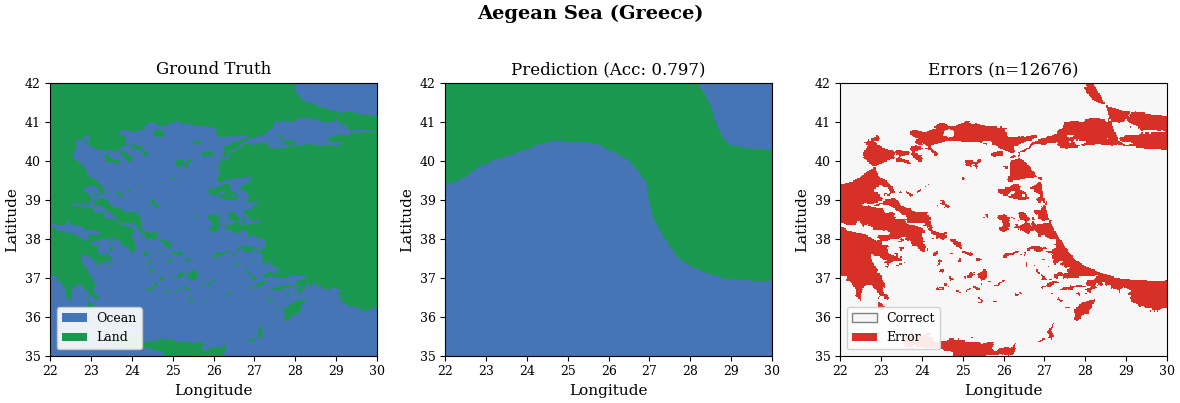

Saved: content/indo.png


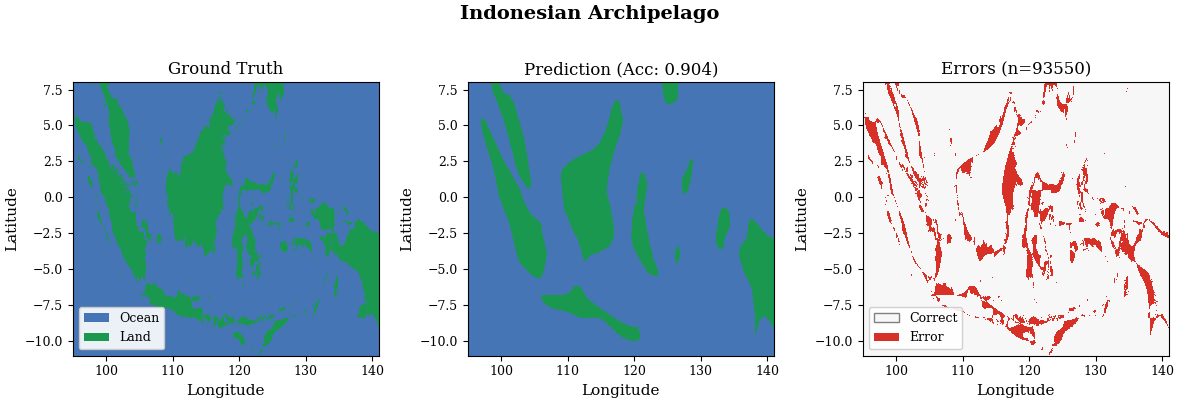

Saved: content/carib.png


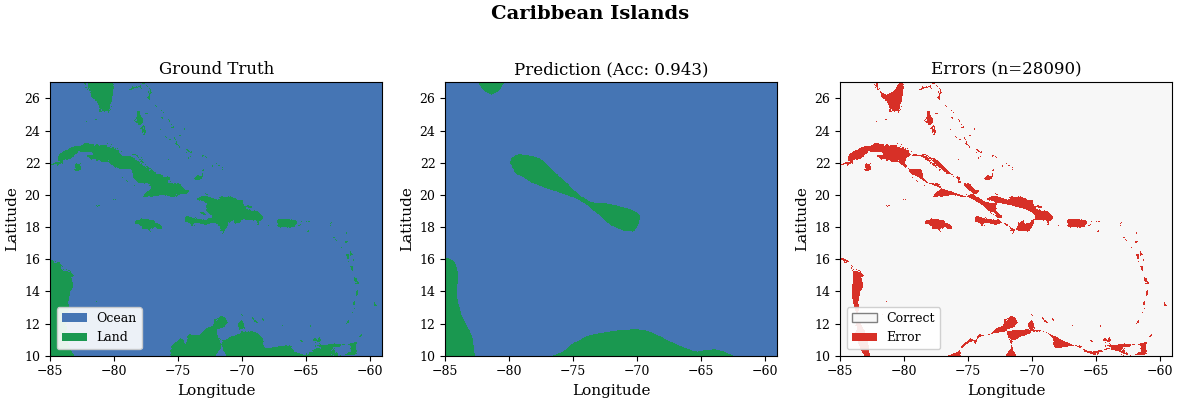

In [9]:
fig, metrics = plot_region_comparison(
    model_sh,
    region_name='Aegean',
    land_union=land_union,
    resolution=0.03,  # higher resolution for detail
    device=DEVICE,
    save_path='content/aegean_detail.png'
)

fig, metrics = plot_region_comparison(
    model_sh,
    region_name='Indonesia',
    land_union=land_union,
    resolution=0.03,  # higher resolution for detail
    device=DEVICE,
    save_path='content/indo.png'
)

fig, metrics = plot_region_comparison(
    model_sh,
    region_name='Caribbean',
    land_union=land_union,
    resolution=0.03,  # higher resolution for detail
    device=DEVICE,
    save_path='content/carib.png'
)

# print(f"\nAegean Sea Results:")
# print(f"  Accuracy: {metrics['accuracy']:.4f}")
# print(f"  Errors: {metrics['errors']} / {metrics['total']}")

## Takeaways:
1. Spherical Harmonics clearly does poorly on a high-resolution land-ocean classification task with fine coastline and island boundaries
2. We need to find out if Masked Slepians (either coastline or around an island) can improve performance!

## Train Slepian coastline mask

In [ ]:
# Configuration for experiments
ENCODER_TYPES = ['spherical_harmonics', 'slepian_hybrid']
L_VALUES = [10, 40]
REGIONS = ['Aegean', 'Indonesia', 'Caribbean']

# Store all results
all_results = {}
    
for encoder_type in ENCODER_TYPES:
    for L in L_VALUES:
        print("\n" + "-"*70)
        print(f"Training: {encoder_type} with L={L}")
        print("-"*70)
        
        if encoder_type == 'spherical_harmonics':
            encoder = SphericalHarmonics(legendre_polys=L)
            model_name = f"SH_L{L}"
        elif encoder_type == 'slepian_hybrid':
            encoder_sh = SphericalHarmonics(legendre_polys=10)
            encoder_slepian = SlepianMaskedEncoder(L=L)
            encoder = SlepianHybridEncoder(encoder_sh, encoder_slepian)
            model_name = f"Hybrid_L{L}"
        
        model = EncoderMLP(encoder, hidden_dim=256, num_layers=3)
        
        print(f"Embedding dim: {encoder.embedding_dim}")
        print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
        
        train_losses, val_losses, best_state = train_model(
            model, 
            train_loader, 
            val_loader,
            DEVICE,
            epochs=200
        )

        results = evaluate_all(model, test_loaders, DEVICE)
        print_results(results, model_name)
        
        result_key = f"{encoder_type}_L{L}"
        all_results[result_key] = {
            'model_name': model_name,
            'encoder_type': encoder_type,
            'L': L,
            'test_results': results,
            'train_losses': train_losses,
            'val_losses': val_losses
        }
        
        # Generate visualizations for each region
        for region in REGIONS:
            save_path = f'content/{encoder_type}_L{L}_{region.lower()}.png'
            
            try:
                fig, metrics = plot_region_comparison(
                    model,
                    region_name=region,
                    land_union=land_union,
                    resolution=0.03,
                    device=DEVICE,
                    save_path=save_path
                )
                
                all_results[result_key][f'{region}_metrics'] = metrics
                
                print(f"\n{region} Results:")
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Errors: {metrics['errors']} / {metrics['total']}")
                
            except Exception as e:
                print(f"Error plotting {region}: {e}")
        
        # Clear CUDA cache if using GPU
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\n" + "="*70)
print("SUMMARY OF ALL EXPERIMENTS")
print("="*70)

for key, result in all_results.items():
    print(f"\n{key}:")
    print(f"  Model: {result['model_name']}")
    print(f"  Test Results:")
    for test_name, metrics in result['test_results'].items():
        print(f"    {test_name}: Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}")


summary_data = []
for key, result in all_results.items():
    for test_name, metrics in result['test_results'].items():
        summary_data.append({
            'encoder_type': result['encoder_type'],
            'L': result['L'],
            'test_set': test_name,
            'accuracy': metrics['accuracy'],
            'f1': metrics['f1'],
            'auc': metrics['auc']
        })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('content/experiment_results_summary.csv', index=False)
print("\nResults saved to: content/experiment_results_summary.csv")